# Part B – Probability Distributions on Transaction Data

Dataset: 220 transactions from January 2023 (`transaction_amount`, `transaction_date`, `transaction_count`, `region`, `transaction_status`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

df = pd.read_csv("spread_locator_dataset - spread_locator_dataset.csv.csv")
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [2]:
df.describe()

,transaction_amount,transaction_date,transaction_count
count,220.000000,220,220.000000
mean,3365.192409,2023-01-15 17:14:10.909090816,2.854545
min,804.420000,2023-01-01 00:00:00,0.000000
25%,2124.205000,2023-01-07 00:00:00,1.750000
50%,3077.715000,2023-01-16 00:00:00,3.000000
75%,3950.737500,2023-01-23 06:00:00,4.000000
max,20462.840000,2023-01-31 00:00:00,9.000000
std,1985.705409,NaN,1.797189


## 1. Bernoulli and Binomial Distribution

### Bernoulli – transaction occurrence

Each transaction is one trial: Success = 1, Fail = 0.

p (success) : 0.4455
q (fail)    : 0.5545
Mean        : 0.4455
Variance    : 0.247


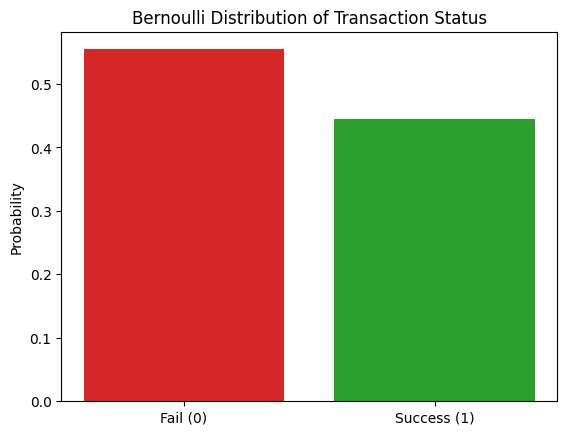

In [3]:
df["success"] = (df["transaction_status"] == "Success").astype(int)

p = df["success"].mean()
print("p (success) :", round(p, 4))
print("q (fail)    :", round(1 - p, 4))
print("Mean        :", round(stats.bernoulli.mean(p), 4))
print("Variance    :", round(stats.bernoulli.var(p), 4))

plt.bar(["Fail (0)", "Success (1)"], [1 - p, p], color=["tab:red", "tab:green"])
plt.ylabel("Probability")
plt.title("Bernoulli Distribution of Transaction Status")
plt.show()

p ≈ 0.445, so a single transaction succeeds a little less than half the time. Variance p(1−p) ≈ 0.247 is close to the maximum 0.25, so the outcome of one transaction is very uncertain.

### Binomial – weekly count

Number of successful transactions in each week follows Binomial(n = transactions in that week, p).

In [4]:
df["week"] = (df["transaction_date"].dt.day - 1) // 7 + 1

weekly = df.groupby("week").agg(n=("success", "size"), successes=("success", "sum"))
weekly["expected"] = (weekly["n"] * p).round(2)
weekly["lower_95"] = stats.binom.ppf(0.025, weekly["n"], p)
weekly["upper_95"] = stats.binom.ppf(0.975, weekly["n"], p)
weekly["P(X = k)"] = stats.binom.pmf(weekly["successes"], weekly["n"], p).round(4)
weekly

,n,successes,expected,lower_95,upper_95,P(X = k)
week,,,,,,
1,57,22,25.39,18.0,33.0,0.0715
2,44,23,19.60,13.0,26.0,0.0706
3,49,21,21.83,15.0,29.0,0.1114
4,44,17,19.60,13.0,26.0,0.0896
5,26,15,11.58,7.0,17.0,0.0636


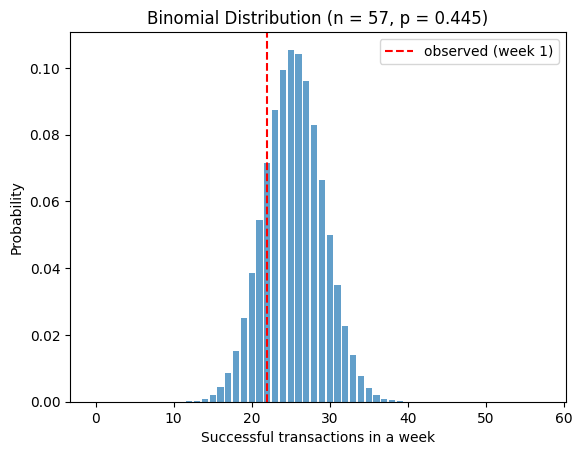

In [5]:
n = weekly.loc[1, "n"]
k = np.arange(0, n + 1)

plt.bar(k, stats.binom.pmf(k, n, p), alpha=0.7)
plt.axvline(weekly.loc[1, "successes"], color="red", linestyle="--", label="observed (week 1)")
plt.xlabel("Successful transactions in a week")
plt.ylabel("Probability")
plt.title(f"Binomial Distribution (n = {n}, p = {p:.3f})")
plt.legend()
plt.show()

All weekly success counts lie inside the 95% range given by the Binomial model, so the Binomial distribution fits the weekly counts well. (Week 5 has only 3 days, so it has a smaller n.)

## 2. Poisson Distribution – transactions per day

In [6]:
daily = df.groupby("transaction_date").size()

lam = daily.mean()
print("λ (mean per day) :", round(lam, 3))
print("Variance         :", round(daily.var(), 3))
print("Variance / mean  :", round(daily.var() / lam, 3))

λ (mean per day) : 7.097
Variance         : 5.29
Variance / mean  : 0.745


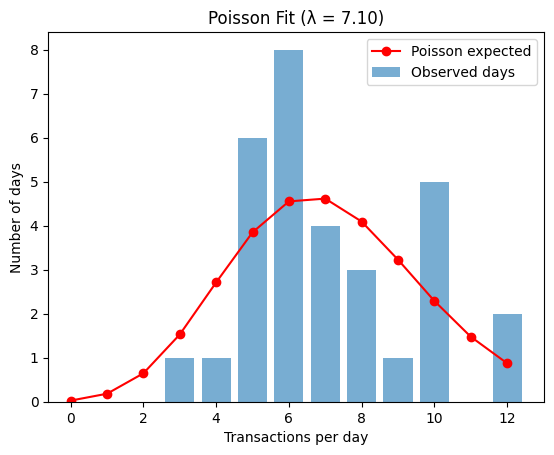

In [7]:
observed = daily.value_counts().sort_index()
k = np.arange(0, daily.max() + 1)
expected = stats.poisson.pmf(k, lam) * len(daily)

plt.bar(observed.index, observed.values, alpha=0.6, label="Observed days")
plt.plot(k, expected, "ro-", label="Poisson expected")
plt.xlabel("Transactions per day")
plt.ylabel("Number of days")
plt.title(f"Poisson Fit (λ = {lam:.2f})")
plt.legend()
plt.show()

In [8]:
# chi-square goodness of fit (grouped so that expected counts are not too small)
bins = [0, 5, 6, 7, 8, 9, np.inf]
obs_g = pd.cut(daily, bins=bins, right=False).value_counts().sort_index().values
cdf = stats.poisson.cdf(np.array(bins[1:]) - 1, lam)
exp_g = np.diff(np.concatenate([[0], cdf])) * len(daily)
exp_g[-1] = len(daily) - exp_g[:-1].sum()

chi2, p_val = stats.chisquare(obs_g, exp_g, ddof=1)
print("Chi-square :", round(chi2, 3))
print("p-value    :", round(p_val, 4))
print("P(more than 10 transactions in a day):", round(stats.poisson.sf(10, lam), 4))

Chi-square : 6.137
p-value    : 0.1891
P(more than 10 transactions in a day): 0.1055


The average is about 7.1 transactions per day and variance is close to the mean, which is what a Poisson process expects. The chi-square p-value is above 0.05, so the Poisson model is not rejected for daily counts.

## 3. Log-Normal and Power Law – transaction amounts

In [9]:
amount = df["transaction_amount"].values

# Log-Normal
shape, loc, scale = stats.lognorm.fit(amount, floc=0)
print("Log-Normal: σ =", round(shape, 4), ", μ =", round(np.log(scale), 4))

# Power Law (Pareto) with xmin = smallest amount
xmin = amount.min()
alpha = 1 + len(amount) / np.sum(np.log(amount / xmin))
print("Power Law : α =", round(alpha, 4), ", xmin =", xmin)

Log-Normal: σ = 0.4749 , μ = 8.0007
Power Law : α = 1.763 , xmin = 804.42


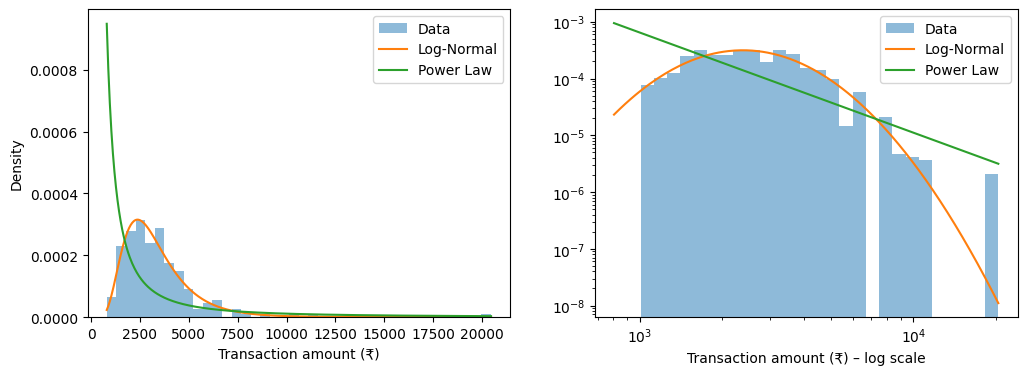

In [10]:
x = np.linspace(amount.min(), amount.max(), 500)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(amount, bins=40, density=True, alpha=0.5, label="Data")
plt.plot(x, stats.lognorm.pdf(x, shape, 0, scale), label="Log-Normal")
plt.plot(x, stats.pareto.pdf(x, alpha - 1, 0, xmin), label="Power Law")
plt.xlabel("Transaction amount (₹)")
plt.ylabel("Density")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(amount, bins=np.logspace(np.log10(amount.min()), np.log10(amount.max()), 30), density=True, alpha=0.5, label="Data")
plt.plot(x, stats.lognorm.pdf(x, shape, 0, scale), label="Log-Normal")
plt.plot(x, stats.pareto.pdf(x, alpha - 1, 0, xmin), label="Power Law")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Transaction amount (₹) – log scale")
plt.legend()

plt.show()

In [11]:
models = {
    "Normal": (stats.norm, stats.norm.fit(amount)),
    "Log-Normal": (stats.lognorm, (shape, 0, scale)),
    "Power Law": (stats.pareto, (alpha - 1, 0, xmin)),
}

rows = []
for name, (dist, params) in models.items():
    ll = np.sum(dist.logpdf(amount, *params))
    ks = stats.kstest(amount, dist.cdf, args=params)
    rows.append([name, round(ll, 2), round(4 - 2 * ll, 2), round(ks.statistic, 4), ks.pvalue])

fit_table = pd.DataFrame(rows, columns=["distribution", "log_likelihood", "AIC", "KS_stat", "KS_p_value"])
fit_table

,distribution,log_likelihood,AIC,KS_stat,KS_p_value
0,Normal,-1982.29,3968.57,0.1404,3.032403e-04
1,Log-Normal,-1908.51,3821.03,0.0378,8.998795e-01
2,Power Law,-2039.67,4083.34,0.3216,9.570178e-21


The Log-Normal curve follows the histogram closely and has the lowest AIC. Its KS p-value (≈ 0.90) is well above 0.05. The Power Law puts too much weight on values near the minimum and decays too slowly, so it is rejected (KS p-value ≈ 0).

## 4. Q-Q Plot – test for normality

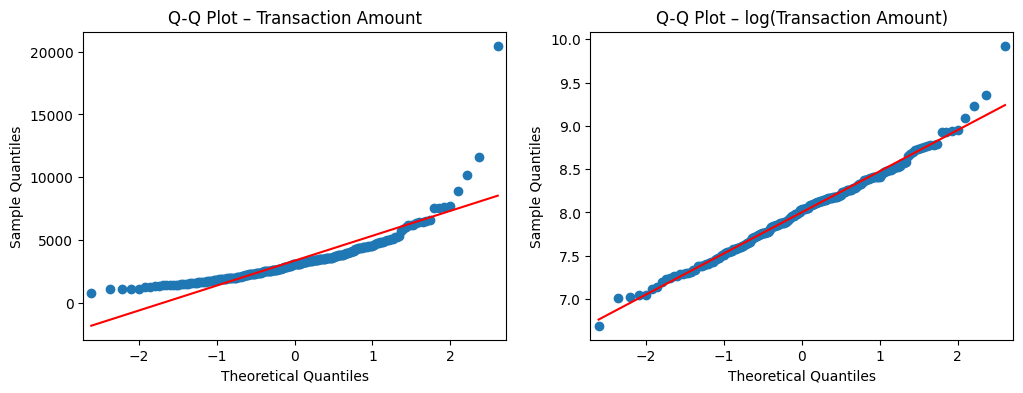

Shapiro-Wilk (amount)     : p = 1.9104196066327425e-18
Shapiro-Wilk (log amount) : p = 0.1061
Skewness : 3.73


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sm.qqplot(amount, line="s", ax=ax[0])
ax[0].set_title("Q-Q Plot – Transaction Amount")

sm.qqplot(np.log(amount), line="s", ax=ax[1])
ax[1].set_title("Q-Q Plot – log(Transaction Amount)")

plt.show()

print("Shapiro-Wilk (amount)     : p =", stats.shapiro(amount).pvalue)
print("Shapiro-Wilk (log amount) : p =", round(stats.shapiro(np.log(amount)).pvalue, 4))
print("Skewness :", round(stats.skew(amount), 3))

For the raw amounts the points bend upward away from the line at the right end, which means a long right tail (skewness ≈ 3.7). Shapiro-Wilk p < 0.05, so the amounts are **not normal**.
After taking log, the points lie almost on the line and p > 0.05, which again supports the Log-Normal model.

## 5. Box-Cox Transform

In [13]:
amount_bc, lmbda = stats.boxcox(amount)
print("Best λ :", round(lmbda, 4))
print("Skewness before :", round(stats.skew(amount), 3))
print("Skewness after  :", round(stats.skew(amount_bc), 3))
print("Shapiro-Wilk p after :", round(stats.shapiro(amount_bc).pvalue, 4))

Best λ : -0.1808
Skewness before : 3.73
Skewness after  : -0.011
Shapiro-Wilk p after : 0.6419


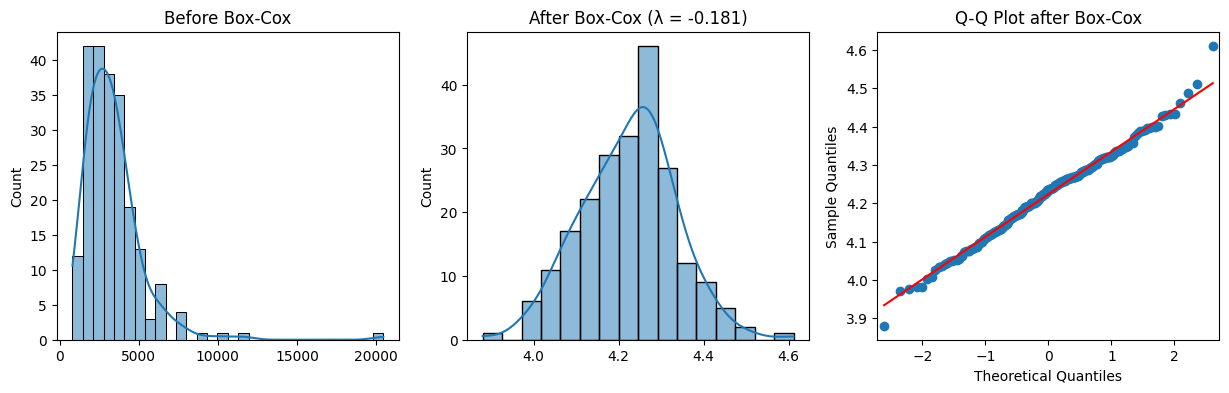

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(amount, kde=True, ax=ax[0])
ax[0].set_title("Before Box-Cox")

sns.histplot(amount_bc, kde=True, ax=ax[1])
ax[1].set_title(f"After Box-Cox (λ = {lmbda:.3f})")

sm.qqplot(amount_bc, line="s", ax=ax[2])
ax[2].set_title("Q-Q Plot after Box-Cox")

plt.show()

In [15]:
# variance across regions before and after transform
df["amount_bc"] = amount_bc
df.groupby("region")[["transaction_amount", "amount_bc"]].std()

,transaction_amount,amount_bc
region,,
East,1327.819944,0.114986
North,2956.618560,0.109406
South,1866.419207,0.113078
West,1653.616538,0.107899


λ is close to 0, and Box-Cox with λ = 0 is the log transform, so this matches the Log-Normal result. After the transform the skewness is almost 0, the histogram is symmetric and the Q-Q plot is straight. The spread between regions is also more even, so the variance is stabilised.

## 6. Z-scores and P(amount > ₹5000)

In [16]:
df["z_score"] = stats.zscore(amount)

mean, std = amount.mean(), amount.std()
z_5000 = (5000 - mean) / std
print("Mean :", round(mean, 2), " Std :", round(std, 2))
print("z for ₹5000 :", round(z_5000, 4))

print("\nP(X > 5000) using Normal (z)  :", round(stats.norm.sf(z_5000), 4))
print("P(X > 5000) using Log-Normal  :", round(stats.lognorm.sf(5000, shape, 0, scale), 4))
print("P(X > 5000) from data         :", round((amount > 5000).mean(), 4))

Mean : 3365.19  Std : 1981.19
z for ₹5000 : 0.8252

P(X > 5000) using Normal (z)  : 0.2046
P(X > 5000) using Log-Normal  : 0.1384
P(X > 5000) from data         : 0.1136


In [17]:
df[np.abs(df["z_score"]) > 3][["transaction_id", "transaction_amount", "z_score"]]

,transaction_id,transaction_amount,z_score
113,2e93bb0d-053d-406e-9573-3f182448136d,10215.09,3.457471
179,3c47b2b6-8b97-41ee-834a-702a6560f39b,11615.37,4.164259
209,c4f47850-33b7-437d-8d2a-f283f0456e1a,20462.84,8.630001


₹5000 is about 0.83 standard deviations above the mean. The normal model gives P ≈ 0.205, but in the data only about 11.4% of transactions are above ₹5000. The Log-Normal model gives ≈ 0.138, which is much closer. The normal model is wrong here because the large outliers (|z| > 3) inflate the standard deviation.

## 7. PDF and CDF of transaction amounts

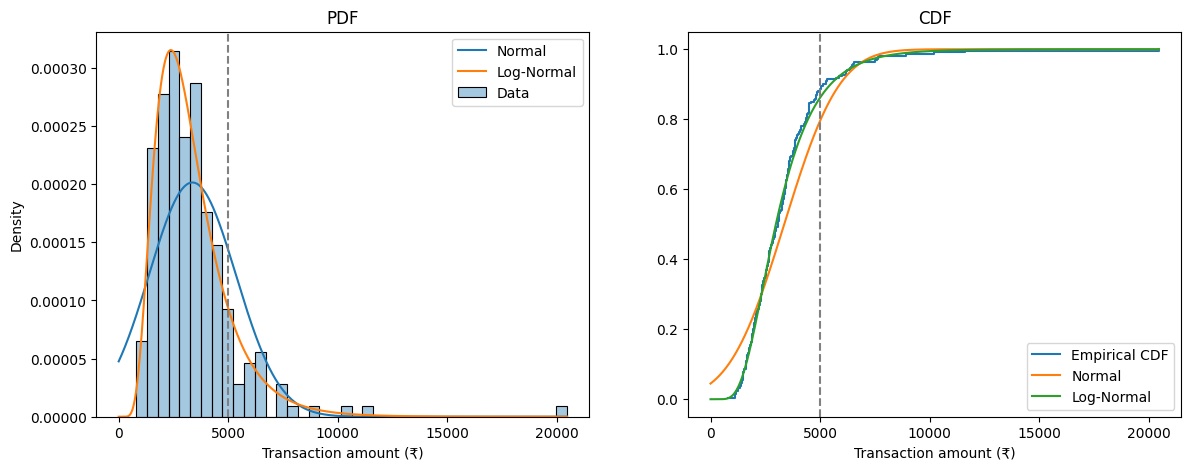

In [18]:
x = np.linspace(0, amount.max(), 1000)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(amount, bins=40, stat="density", alpha=0.4, ax=ax[0], label="Data")
ax[0].plot(x, stats.norm.pdf(x, mean, std), label="Normal")
ax[0].plot(x, stats.lognorm.pdf(x, shape, 0, scale), label="Log-Normal")
ax[0].axvline(5000, color="grey", linestyle="--")
ax[0].set_title("PDF")
ax[0].set_xlabel("Transaction amount (₹)")
ax[0].legend()

ax[1].plot(np.sort(amount), np.arange(1, len(amount) + 1) / len(amount), drawstyle="steps-post", label="Empirical CDF")
ax[1].plot(x, stats.norm.cdf(x, mean, std), label="Normal")
ax[1].plot(x, stats.lognorm.cdf(x, shape, 0, scale), label="Log-Normal")
ax[1].axvline(5000, color="grey", linestyle="--")
ax[1].set_title("CDF")
ax[1].set_xlabel("Transaction amount (₹)")
ax[1].legend()

plt.show()

In [19]:
for q in [0.25, 0.5, 0.75, 0.9, 0.95]:
    print(f"{int(q * 100)}th percentile: data = {np.quantile(amount, q):.2f}, Log-Normal = {stats.lognorm.ppf(q, shape, 0, scale):.2f}")

25th percentile: data = 2124.20, Log-Normal = 2165.51
50th percentile: data = 3077.72, Log-Normal = 2983.16
75th percentile: data = 3950.74, Log-Normal = 4109.54
90th percentile: data = 5136.78, Log-Normal = 5482.79
95th percentile: data = 6433.78, Log-Normal = 6515.30


The PDF peaks at around ₹2500–3000 and has a long tail on the right. The normal PDF is symmetric and even gives probability to negative amounts, while the Log-Normal PDF matches the shape of the data.
The empirical CDF and Log-Normal CDF almost overlap. About 89% of transactions are at or below ₹5000.

## 8. Conclusion

| Variable | Best distribution | Reason |
|---|---|---|
| Transaction status | Bernoulli (p ≈ 0.445) | Only two outcomes per transaction |
| Weekly successful transactions | Binomial (n, p ≈ 0.445) | All weeks fall inside the 95% Binomial range |
| Transactions per day | Poisson (λ ≈ 7.1) | Variance ≈ mean, chi-square test not rejected |
| Transaction amount | **Log-Normal** | Lowest AIC, KS p ≈ 0.90, log Q-Q plot is straight, Box-Cox λ ≈ 0 |

**Log-Normal is the best fit for transaction amounts.** Normal fails because of the right skew, and Power Law fails because the data does not have such a heavy tail.

Insights for decision-making:
- Less than half the transactions succeed, so improving the success rate should be a priority.
- With λ ≈ 7.1 per day, the Poisson model can be used to plan capacity, e.g. a day with more than 10 transactions happens only about 10% of the time.
- Probability of a transaction above ₹5000 should be taken from the Log-Normal model (≈ 14%), not the normal model (≈ 20%), otherwise high-value transactions are overestimated.
- Transactions with |z| > 3 are rare and can be flagged for fraud checks or manual review.
- For any model that assumes normality (regression, t-test), the amounts should first be log / Box-Cox transformed.